Data

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sklearn

## Read the data 

In [60]:

df = pd.read_excel('./data/raw/Dry_Bean_Dataset.xlsx')

In [61]:
# <!--  data frame -->
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [62]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  str    
dtypes: float64(14), int64(2

Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64

Split the data yourself: use 80% for training and 20% for testing with random_state=42 and
stratify=y.

In [63]:
# make scaling with MinMaxScaler and update the feature columns in-place
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
x = df.drop('Class', axis=1)
y = df['Class']

x_scaled = scaler.fit_transform(x)
df = pd.DataFrame(x_scaled, columns=x.columns, index=x.index)
df['Class'] = y
df.head()

# make encoding for class column
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Class'] = le.fit_transform(df['Class'])
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,0.034053,0.058574,0.044262,0.152142,0.122612,0.477797,0.033107,0.070804,0.671024,0.922824,0.934823,0.786733,0.593432,0.833049,0.750996,0.980620,5
1,0.035500,0.077557,0.030479,0.178337,0.051577,0.278472,0.034991,0.073577,0.735504,0.871514,0.793138,0.903549,0.547447,0.967315,0.884987,0.974979,5
2,0.038259,0.068035,0.052633,0.158190,0.131521,0.496448,0.037126,0.078816,0.716671,0.932141,0.914511,0.773514,0.582016,0.800942,0.736200,0.987196,5
3,0.040940,0.082942,0.048548,0.177691,0.091623,0.403864,0.041389,0.083854,0.731365,0.761614,0.826871,0.829912,0.552408,0.854744,0.799846,0.893675,5
4,0.041504,0.065313,0.032862,0.200679,0.025565,0.165680,0.040123,0.084906,0.700538,0.949832,0.988408,0.951583,0.510741,1.000000,0.941770,0.989116,5


In [64]:
# Split the data yourself: use 80% for training and 20% for testing with random_state=42 and
# stratify=y.
from sklearn.model_selection import train_test_split
x = df.drop('Class', axis=1)
y = df['Class']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

#  Generate a scatterplot matrix for a representative subset of features (choose any 5
# features) to visualize pairwise relationships and class separability. Then generate a
# heatmap of the full feature correlation matrix to detect highly correlated attributes. Write
# a summary of what you noticed — specifically which features appear most separable
# across classes and which features are redundant due to high correlation.

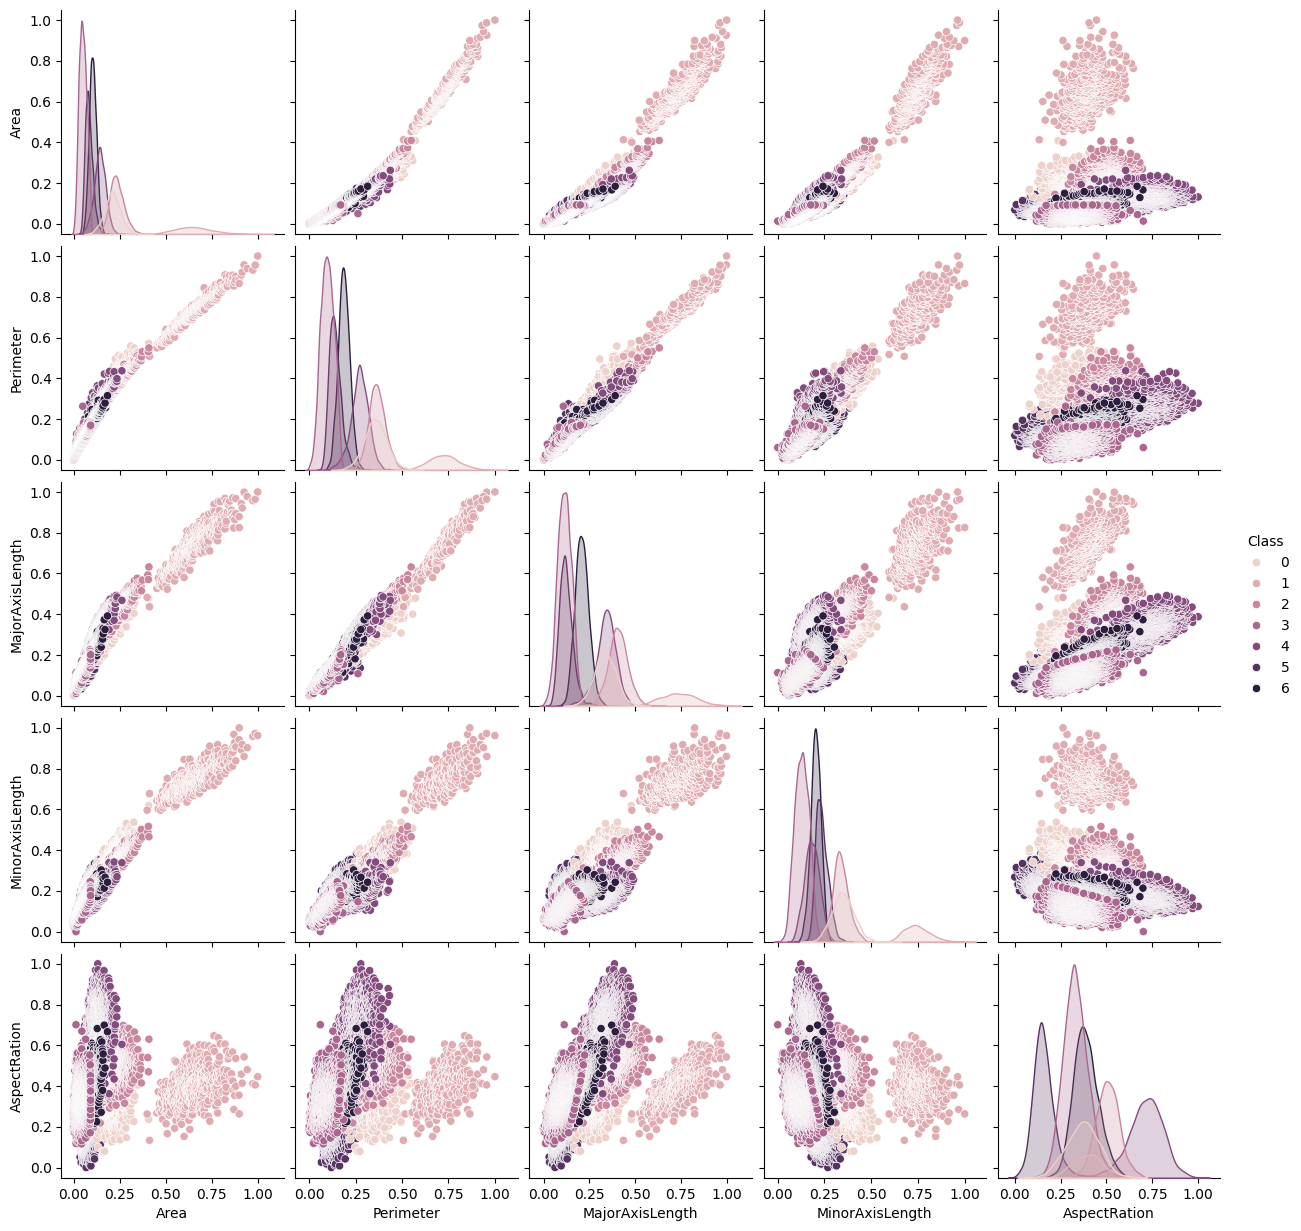

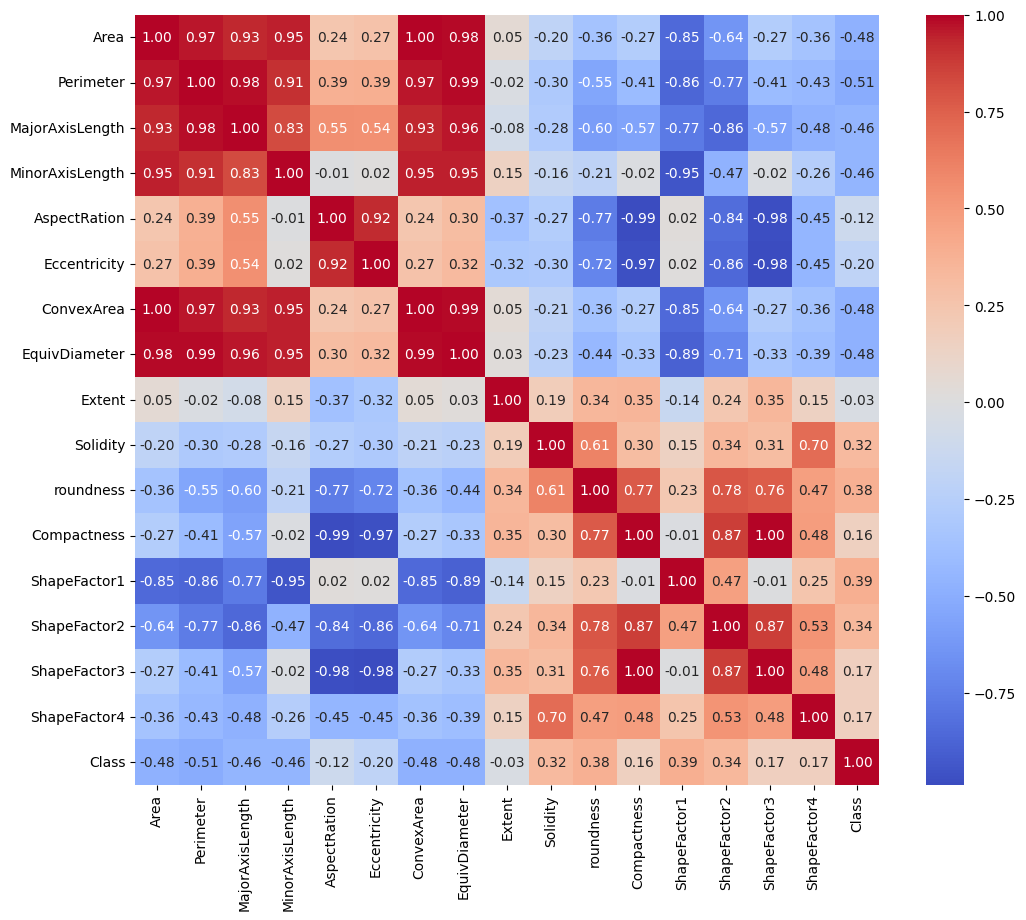

In [65]:


# scatterplot matrix
sns.pairplot(df, vars=['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRation'], hue='Class')
plt.show()

# heatmap of the full feature correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()





### a summary of what you noticed — specifically which features appear most separable
 summary : the features that appear most separable across classes are Area, Perimeter, MajorAxisLength,  MinorAxisLength, and AspectRation. These features show distinct clusters for different classes in the scatterplot matrix. The heatmap of the correlation matrix indicates that some features are highly correlated, such as Area and Perimeter, which may suggest redundancy. It is important to consider feature selection or dimensionality reduction techniques to address this redundancy in future modeling steps.
###  across classes and which features are redundant due to high correlation.

1.Area
2.Perimeter
3.MajorAxisLength
4.MinorAxisLength
5.AspectRatio

In [66]:
df.duplicated().sum()


np.int64(68)

In [67]:
# Ensure data is in the correct format for downstream processes: verify there are no
# missing values, confirm all features are numerical (the Class column is categorical —
# encode it), check for and remove any duplicate rows, and report how many samples
# remain after cleaning.
df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.duplicated().sum()




np.int64(0)

### Fit a Decision Tree classifier to the training data using default settings. Visualize the tree
### limited to depth 4 for readability. Interpret the top 3 splitting nodes: what feature is used,
### what threshold is applied, and which classes does it help separate? Report training
### accuracy, test accuracy, and display the Confusion Matrix. Identify which bean varieties
### are most often misclassified.

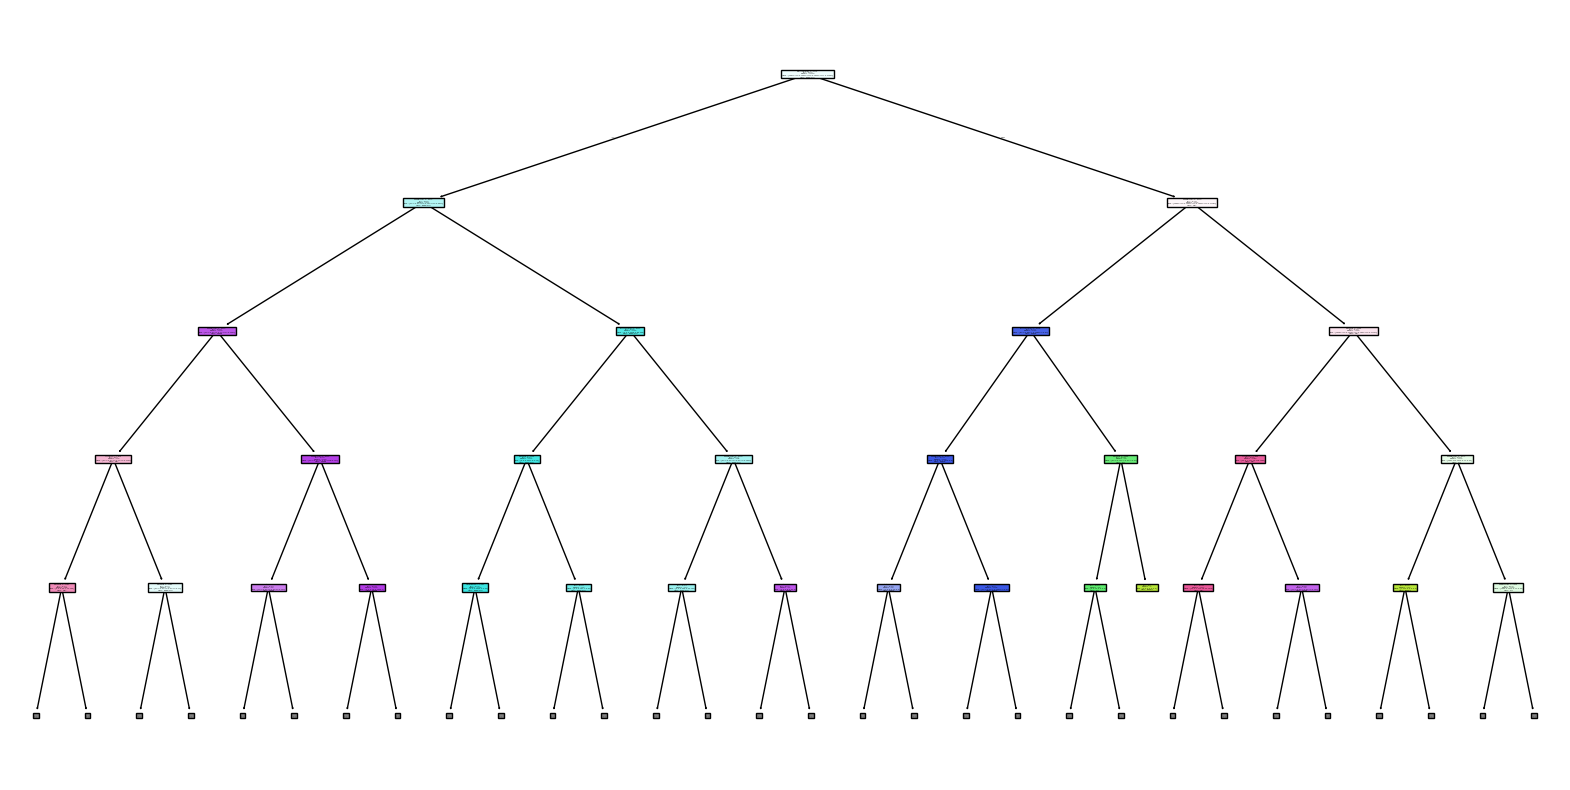

Training Accuracy: 1.0000
Test Accuracy: 0.8920


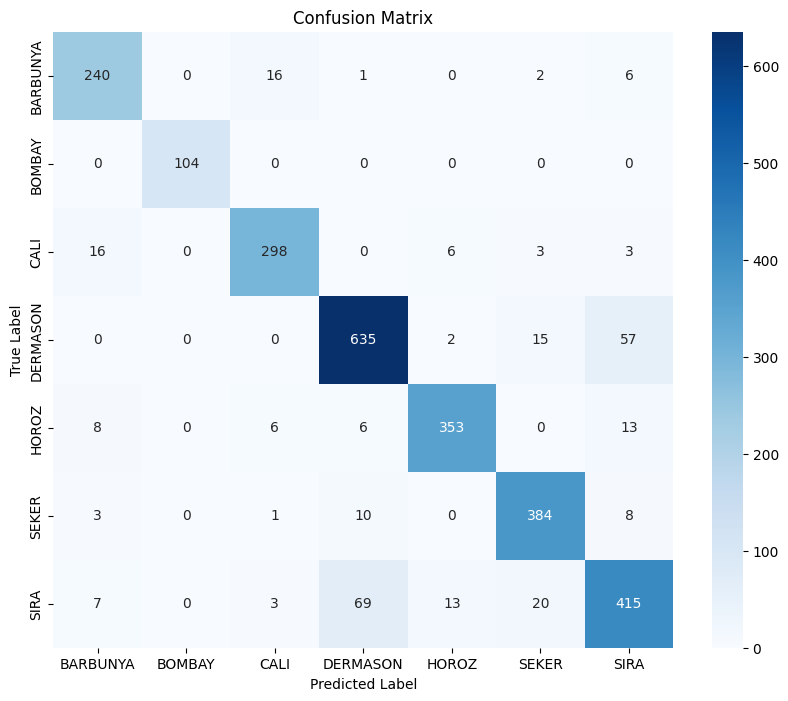


Classification Report:
              precision    recall  f1-score   support

    BARBUNYA       0.88      0.91      0.89       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.92      0.91      0.92       326
    DERMASON       0.88      0.90      0.89       709
       HOROZ       0.94      0.91      0.93       386
       SEKER       0.91      0.95      0.93       406
        SIRA       0.83      0.79      0.81       527

    accuracy                           0.89      2723
   macro avg       0.91      0.91      0.91      2723
weighted avg       0.89      0.89      0.89      2723



In [70]:


from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns

dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train, y_train)
plt.figure(figsize=(20, 10))
plot_tree(dt, max_depth=4, filled=True, feature_names=x.columns, class_names=le.classes_)
plt.show()

# Get predictions
y_train_pred = dt.predict(x_train)
y_test_pred = dt.predict(x_test)

# Report accuracies
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=le.classes_))




#### Try at least three different approaches to improve the Decision Tree: experiment with
different splitting criteria (Gini vs Entropy), vary the max_depth from shallow to deep (try
at least 4 depth values), and apply cost-complexity pruning by tuning the ccp_alpha
parameter. For ccp_alpha, plot test accuracy vs alpha values and identify the best value.
Present a comparison table of all variants showing train accuracy, test accuracy, and
tree depth. Comment on whether pruning improves generalization and why.

In [ ]:



dt_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)

depths = [3, 5, 7, None]
results = []

for depth in depths:
    for criterion, model in [('gini', dt_gini), ('entropy', dt_entropy)]:
        model.set_params(criterion=criterion, max_depth=depth)
        model.fit(x_train, y_train)
        
        y_train_pred = model.predict(x_train)
        y_test_pred = model.predict(x_test)
        
        train_acc = accuracy_score(y_train, y_train_pred)
        test_acc = accuracy_score(y_test, y_test_pred)
        
        results.append({
            'Criterion': criterion,
            'Max Depth': depth if depth is not None else 'None',
            'Train Accuracy': train_acc,
            'Test Accuracy': test_acc
        })


results_df = pd.DataFrame(results)
print(results_df)   


  Criterion Max Depth  Train Accuracy  Test Accuracy
0      gini         3        0.778288       0.773044
1   entropy         3        0.810158       0.799119
2      gini         5        0.893369       0.881014
3   entropy         5        0.904298       0.887624
4      gini         7        0.926892       0.900845
5   entropy         7        0.928453       0.905619
6      gini      None        1.000000       0.892031
7   entropy      None        1.000000       0.897907


#### Apply the Bagging strategy to classify test set samples using both SVM and Decision
Tree as base estimators (train one Bagging model per estimator type). For each, display
the test accuracy and Confusion Matrix. Then compare both: which base estimator
benefits more from bagging and explain why bagging helps high-variance models more
than high-bias models.

Training Bagging models...

Bagging with Decision Tree - Test Accuracy: 0.9181
Bagging with SVM - Test Accuracy: 0.9214



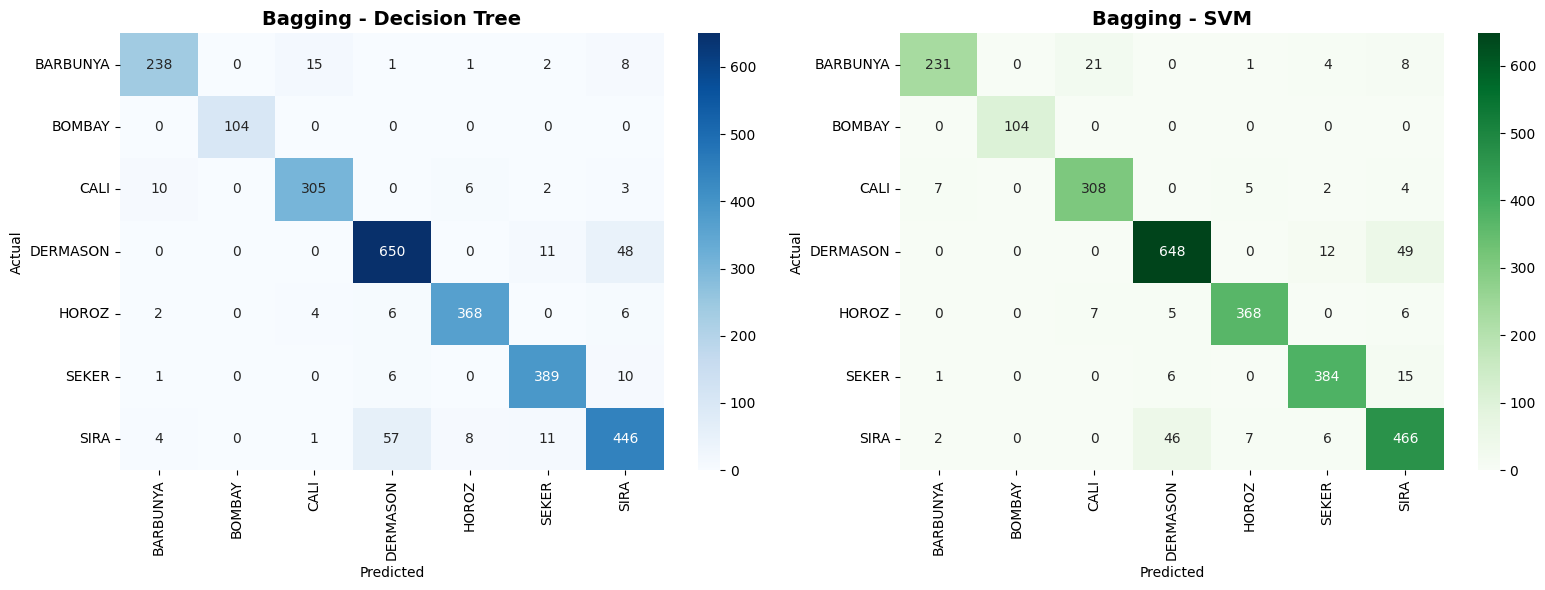


Decision Tree Classification Report:
              precision    recall  f1-score   support

    BARBUNYA       0.93      0.90      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.94      0.94      0.94       326
    DERMASON       0.90      0.92      0.91       709
       HOROZ       0.96      0.95      0.96       386
       SEKER       0.94      0.96      0.95       406
        SIRA       0.86      0.85      0.85       527

    accuracy                           0.92      2723
   macro avg       0.93      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723


SVM Classification Report:
              precision    recall  f1-score   support

    BARBUNYA       0.96      0.87      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.92      0.94      0.93       326
    DERMASON       0.92      0.91      0.92       709
       HOROZ       0.97      0.95      0.96       386
       SEKER

In [ ]:


from sklearn.ensemble import BaggingClassifier
from sklearn.svm import SVC

# Initialize base estimators
dt_base = DecisionTreeClassifier(random_state=42)
svm_base = SVC(random_state=42)

# Create Bagging models
bagging_dt = BaggingClassifier(estimator=dt_base, n_estimators=100, random_state=42)
bagging_svm = BaggingClassifier(estimator=svm_base, n_estimators=100, random_state=42)

# Train models
bagging_dt.fit(x_train, y_train)
bagging_svm.fit(x_train, y_train)

# Get predictions
y_pred_dt = bagging_dt.predict(x_test)
y_pred_svm = bagging_svm.predict(x_test)

# Calculate accuracies
acc_dt = accuracy_score(y_test, y_pred_dt)
acc_svm = accuracy_score(y_test, y_pred_svm)

# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix - Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=le.classes_, yticklabels=le.classes_)
axes[0].set_title('Bagging - Decision Tree', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Confusion Matrix - SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=le.classes_, yticklabels=le.classes_)
axes[1].set_title('Bagging - SVM', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

# Classification Reports

comparison = {
    'Base Estimator': ['Decision Tree', 'SVM'],
    'Test Accuracy': [f'{acc_dt:.4f}', f'{acc_svm:.4f}'],
    'Accuracy Gain': [f'{acc_dt - accuracy_score(y_test, dt.predict(x_test)):.4f}',
                      f'{acc_svm - accuracy_score(y_test, SVC(random_state=42).fit(x_train, y_train).predict(x_test)):.4f}']
}
comparison_df = pd.DataFrame(comparison)



## 2. Boosting

Boosting is an ensemble method that sequentially trains weak learners and combines them to create a strong learner. AdaBoost adjusts sample weights after each iteration.

AdaBoost Test Accuracy: 0.8884


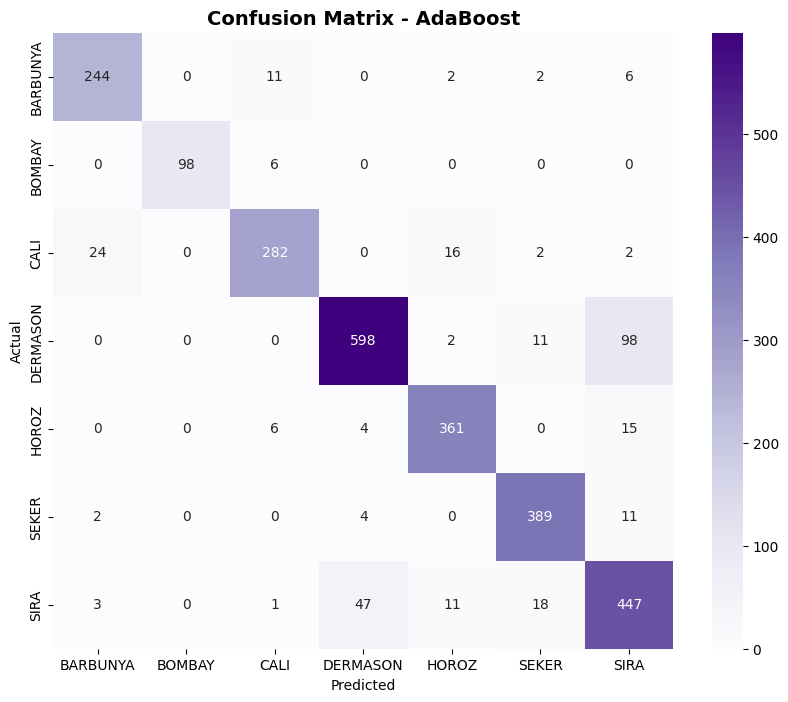


AdaBoost Classification Report:
              precision    recall  f1-score   support

    BARBUNYA       0.89      0.92      0.91       265
      BOMBAY       1.00      0.94      0.97       104
        CALI       0.92      0.87      0.89       326
    DERMASON       0.92      0.84      0.88       709
       HOROZ       0.92      0.94      0.93       386
       SEKER       0.92      0.96      0.94       406
        SIRA       0.77      0.85      0.81       527

    accuracy                           0.89      2723
   macro avg       0.91      0.90      0.90      2723
weighted avg       0.89      0.89      0.89      2723



In [ ]:
from sklearn.ensemble import AdaBoostClassifier

# Train AdaBoost with Decision Tree
ada_boost = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3), 
                               n_estimators=50, random_state=42)
ada_boost.fit(x_train, y_train)

# Predictions
y_pred_ada = ada_boost.predict(x_test)

# Accuracy
acc_ada = accuracy_score(y_test, y_pred_ada)

# Confusion Matrix
cm_ada = confusion_matrix(y_test, y_pred_ada)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_ada, annot=True, fmt='d', cmap='Purples', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - AdaBoost', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


## 3. Stacking

Stacking combines multiple models using a meta-learner. Base models make predictions, and the meta-learner learns from their outputs.

c:\Users\LAP ME\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Stacking Test Accuracy: 0.9170


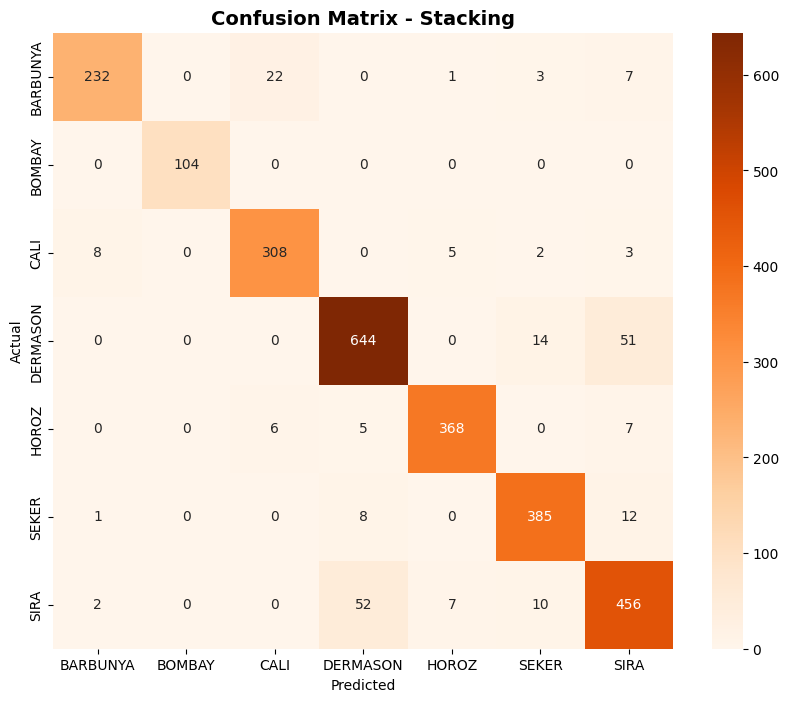


Stacking Classification Report:
              precision    recall  f1-score   support

    BARBUNYA       0.95      0.88      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.92      0.94      0.93       326
    DERMASON       0.91      0.91      0.91       709
       HOROZ       0.97      0.95      0.96       386
       SEKER       0.93      0.95      0.94       406
        SIRA       0.85      0.87      0.86       527

    accuracy                           0.92      2723
   macro avg       0.93      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# Define base models
base_models = [
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('svm', SVC(kernel='rbf', random_state=42))
]

# Meta-learner
meta_learner = LogisticRegression(random_state=42)

# Stacking Classifier
stacking_clf = StackingClassifier(estimators=base_models, final_estimator=meta_learner, cv=5)
stacking_clf.fit(x_train, y_train)

# Predictions
y_pred_stack = stacking_clf.predict(x_test)

# Accuracy
acc_stack = accuracy_score(y_test, y_pred_stack)

# Confusion Matrix
cm_stack = confusion_matrix(y_test, y_pred_stack)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_stack, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Stacking', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


## 4. Voting Ensemble

Voting combines predictions from multiple models. Hard voting uses majority voting; soft voting averages prediction probabilities.

Hard Voting Test Accuracy: 0.9196
Soft Voting Test Accuracy: 0.9137



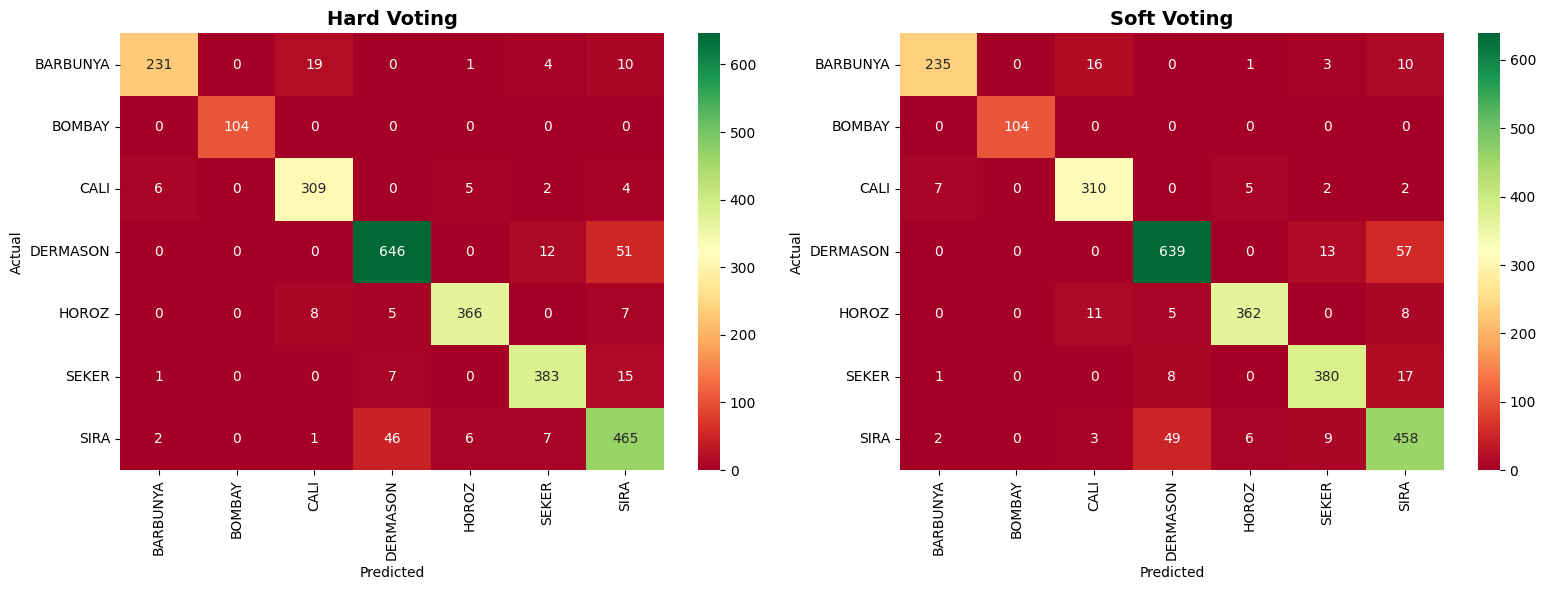

Hard Voting Classification Report:
              precision    recall  f1-score   support

    BARBUNYA       0.96      0.87      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.92      0.95      0.93       326
    DERMASON       0.92      0.91      0.91       709
       HOROZ       0.97      0.95      0.96       386
       SEKER       0.94      0.94      0.94       406
        SIRA       0.84      0.88      0.86       527

    accuracy                           0.92      2723
   macro avg       0.94      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



In [ ]:
from sklearn.ensemble import VotingClassifier

# Define estimators
voting_estimators = [
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('svm', SVC(kernel='rbf', random_state=42, probability=True)),
    ('lr', LogisticRegression(random_state=42, max_iter=1000))
]

# Hard Voting
voting_hard = VotingClassifier(estimators=voting_estimators, voting='hard')
voting_hard.fit(x_train, y_train)
y_pred_hard = voting_hard.predict(x_test)
acc_hard = accuracy_score(y_test, y_pred_hard)

# Soft Voting
voting_soft = VotingClassifier(estimators=voting_estimators, voting='soft')
voting_soft.fit(x_train, y_train)
y_pred_soft = voting_soft.predict(x_test)
acc_soft = accuracy_score(y_test, y_pred_soft)

# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm_hard = confusion_matrix(y_test, y_pred_hard)
sns.heatmap(cm_hard, annot=True, fmt='d', cmap='RdYlGn', ax=axes[0],
            xticklabels=le.classes_, yticklabels=le.classes_)
axes[0].set_title('Hard Voting', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

cm_soft = confusion_matrix(y_test, y_pred_soft)
sns.heatmap(cm_soft, annot=True, fmt='d', cmap='RdYlGn', ax=axes[1],
            xticklabels=le.classes_, yticklabels=le.classes_)
axes[1].set_title('Soft Voting', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

print("Hard Voting Classification Report:")
print(classification_report(y_test, y_pred_hard, target_names=le.classes_))

## 5. Improving with PCA and Feature Selection

Dimensionality reduction via PCA and feature selection can improve model performance and reduce overfitting.

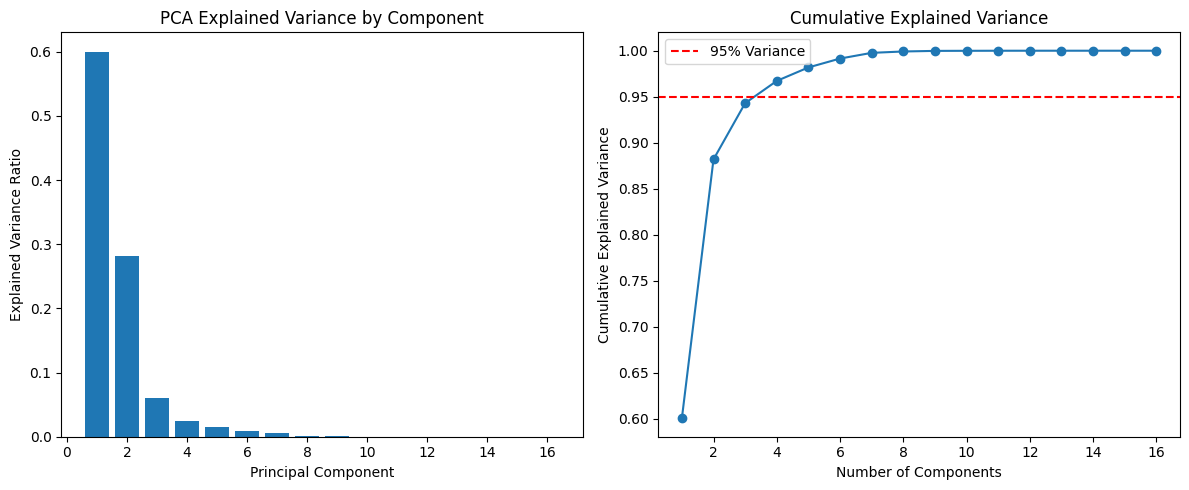

Number of components for 95% variance: 4
Original dimensions: 16
Reduced dimensions: 4

Decision Tree with PCA - Test Accuracy: 0.8498
Decision Tree without PCA - Test Accuracy: 0.8920

Top 10 Selected Features: ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRation', 'ConvexArea', 'EquivDiameter', 'Compactness', 'ShapeFactor1', 'ShapeFactor2']

Decision Tree with Feature Selection - Test Accuracy: 0.8799

DIMENSIONALITY REDUCTION COMPARISON
                  Method  Features  Accuracy
                Original        16  0.892031
               PCA (95%)         4  0.849798
Feature Selection (K=10)        10  0.879912


In [ ]:
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif

# PCA Analysis
pca = PCA()
x_train_pca_all = pca.fit_transform(x_train)

# Calculate cumulative explained variance
cumsum_var = np.cumsum(pca.explained_variance_ratio_)

# Plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.bar(range(1, len(cumsum_var) + 1), pca.explained_variance_ratio_)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Explained Variance by Component')
plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumsum_var) + 1), cumsum_var, marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance')
plt.legend()
plt.tight_layout()
plt.show()

# PCA with optimal components (95% variance)
n_components = np.argmax(cumsum_var >= 0.95) + 1
pca_opt = PCA(n_components=n_components)
x_train_pca = pca_opt.fit_transform(x_train)
x_test_pca = pca_opt.transform(x_test)

# Train model on PCA data
dt_pca = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_pca.fit(x_train_pca, y_train)
y_pred_pca = dt_pca.predict(x_test_pca)
acc_pca = accuracy_score(y_test, y_pred_pca)

print(f"Decision Tree with PCA - Test Accuracy: {acc_pca:.4f}")
print(f"Decision Tree without PCA - Test Accuracy: {accuracy_score(y_test, dt.predict(x_test)):.4f}\n")

# Feature Selection - SelectKBest
# Feature Selection - SelectKBest
selector = SelectKBest(score_func=f_classif, k=10)
x_train_fs = selector.fit_transform(x_train, y_train)
x_test_fs = selector.transform(x_test)

# Get selected features
selected_features = x_train.columns[selector.get_support()].tolist()
print(f"Top 10 Selected Features: {selected_features}\n")

# Train model on selected features

# Train model on selected features
dt_fs = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_fs.fit(x_train_fs, y_train)
y_pred_fs = dt_fs.predict(x_test_fs)
acc_fs = accuracy_score(y_test, y_pred_fs)

print(f"Decision Tree with Feature Selection - Test Accuracy: {acc_fs:.4f}")
# Comparison
comparison_dr = pd.DataFrame({
    'Method': ['Original', 'PCA (95%)', 'Feature Selection (K=10)'],
    'Features': [x_train.shape[1], x_train_pca.shape[1], len(selected_features)],
    'Accuracy': [
        accuracy_score(y_test, dt.predict(x_test)),
        acc_pca,
        acc_fs
    ]
})

print("\n" + "="*60)
print("DIMENSIONALITY REDUCTION COMPARISON")

## 6. Model Comparison Summary

Final comparison of all ensemble methods and dimensionality reduction techniques.

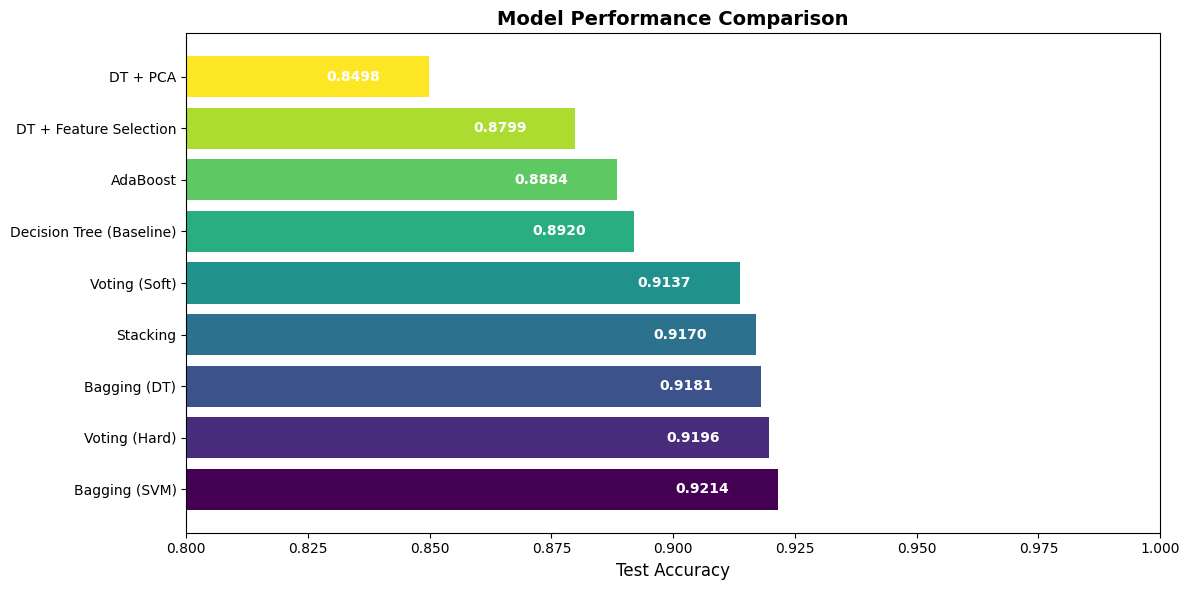

In [79]:
# Compile all results
all_results = pd.DataFrame({
    'Model': [
        'Decision Tree (Baseline)',
        'Bagging (DT)',
        'Bagging (SVM)',
        'AdaBoost',
        'Stacking',
        'Voting (Hard)',
        'Voting (Soft)',
        'DT + PCA',
        'DT + Feature Selection'
    ],
    'Test Accuracy': [
        accuracy_score(y_test, dt.predict(x_test)),
        acc_dt,
        acc_svm,
        acc_ada,
        acc_stack,
        acc_hard,
        acc_soft,
        acc_pca,
        acc_fs
    ]
})

# Sort by accuracy
all_results = all_results.sort_values('Test Accuracy', ascending=False).reset_index(drop=True)

all_results

# Visualization
plt.figure(figsize=(12, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(all_results)))
bars = plt.barh(all_results['Model'], all_results['Test Accuracy'], color=colors)
plt.xlabel('Test Accuracy', fontsize=12)
plt.title('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.xlim(0.8, 1.0)
for i, (idx, row) in enumerate(all_results.iterrows()):
    plt.text(row['Test Accuracy'] - 0.01, i, f"{row['Test Accuracy']:.4f}", 
             va='center', ha='right', fontweight='bold', color='white')
plt.tight_layout()
plt.show()

# Best Model
best_model = all_results.iloc[0]